# 🔋 Deep Reinforcement Learning Energy Management System (EMS)
### Algorithm: PPO (Stable-Baselines3) | Hybrid Microgrid Battery Dispatch
---
**Sections**
- **A** – Installation & Setup
- **B** – Data Pipeline
- **C** – Custom Gymnasium Environment (`MicrogridEnv`)
- **D** – Baselines (Rule-Based + Random)
- **E** – PPO Training
- **F** – Evaluation
- **G** – Visualisations (G1–G5 incl. learning curve & summary table)


## Block A │ Installation & Setup

In [ ]:

# ── Block A: Installation & Setup ───────────────────────────
!pip install -q stable-baselines3==2.3.2 gymnasium==0.29.1 shimmy

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

import stable_baselines3
print("✅  Block A complete")
print(f"    SB3 {stable_baselines3.__version__} | gym {gym.__version__} | numpy {np.__version__} | torch {torch.__version__}")

✅  Block A complete
    SB3 2.3.2 | gym 0.29.1 | numpy 2.0.2 | torch 2.11.0+cu128


## Block B │ Data Pipeline

In [ ]:
# ── B-1  Load CSV ────────────────────────────────────────────
print("⬆️   Please upload your CSV file …")
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Parse timestamp and ensure hour/day columns exist
df["timestamp"] = pd.to_datetime(df["timestamp"])
if "hour_of_day" not in df.columns:
    df["hour_of_day"] = df["timestamp"].dt.hour
if "day_of_week" not in df.columns:
    df["day_of_week"] = df["timestamp"].dt.dayofweek

print(f"   Shape : {df.shape}")
print(f"   Range : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   Cols  : {list(df.columns)}")


⬆️   Please upload your CSV file …


Saving Renewable_energy_dataset (1).csv to Renewable_energy_dataset (1) (2).csv
   Shape : (3546, 21)
   Range : 2023-01-01 00:00:00 → 2023-05-28 17:00:00
   Cols  : ['timestamp', 'solar_pv_output', 'wind_power_output', 'total_renewable_energy', 'solar_irradiance', 'wind_speed', 'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand', 'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge', 'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day', 'day_of_week', 'predicted_solar_pv_output', 'predicted_wind_power_output', 'total_predicted_energy']


In [ ]:
# ── B-2  Dynamic pricing (replaces fixed 3-tier ToU) ─────────
# PPO can adapt to dynamic prices; the rule-based controller cannot.
np.random.seed(SEED)
def assign_tou_price(hour: int) -> float:
    if   hour >= 22 or hour < 6:  return 0.08
    elif hour < 16:               return 0.15
    else:                         return 0.25

# Base ToU + gaussian noise → dynamic price signal
base_prices      = df["hour_of_day"].apply(assign_tou_price).values
noise            = np.random.normal(0, 0.025, len(df))
df["price_actual"] = np.clip(base_prices + noise, 0.05, 0.45)

# ── B-3  Cyclical hour encoding ──────────────────────────────
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# ── B-4  Chronological 80/20 split BEFORE normalisation ──────
split_idx = int(len(df) * 0.80)
df_train  = df.iloc[:split_idx].reset_index(drop=True)
df_test   = df.iloc[split_idx:].reset_index(drop=True)

# ── B-5  Normalise using TRAIN statistics only ────────────────
NORM_COLS = [
    "predicted_solar_pv_output",
    "predicted_wind_power_output",
    "grid_load_demand",
    "price_actual",
]
norm_stats = {}
for col in NORM_COLS:
    lo, hi = df_train[col].min(), df_train[col].max()
    norm_stats[col] = (lo, hi)
    denom = (hi - lo) if (hi - lo) > 1e-8 else 1.0
    df_train[f"{col}_norm"] = (df_train[col] - lo) / denom
    df_test [f"{col}_norm"] = (df_test [col] - lo) / denom

print(f"✅  Block B complete – train: {len(df_train)} rows | test: {len(df_test)} rows")
print(f"   Price range: ${df['price_actual'].min():.3f} – ${df['price_actual'].max():.3f} $/kWh")

✅  Block B complete – train: 2836 rows | test: 710 rows
   Price range: $0.050 – $0.346 $/kWh


## Block C │ Custom Gymnasium Environment

In [ ]:
class MicrogridEnv(gym.Env):
    """
    Single-node hybrid microgrid environment for EMS optimisation.

    Observation (9-dim):
        [SoC, pred_solar_norm, pred_wind_norm, pred_load_norm,
         price_norm, hour_sin, hour_cos, net_renew_norm, soc_delta]

    Action (1-dim, continuous [-1, 1]):
        -1 → maximum discharging  |  +1 → maximum charging
    """
    metadata = {"render_modes": []}

    BAT_CAPACITY_KWH   = 500.0
    BAT_MAX_POWER_KW   = 100.0
    BAT_EFFICIENCY     = 0.95
    SOC_MIN            = 0.20
    SOC_MAX            = 0.80
    SOC_INIT           = 0.50
    DT                 = 1.0
    WEAR_COST_PER_KWH  = 0.0001
    SOC_PENALTY_SCALE  = 5.0
    EXPORT_DISCOUNT    = 0.80
    PEAK_PRICE         = 0.25
    OFFPEAK_PRICE      = 0.08
    # Peak demand charge: penalty per kW when grid import exceeds threshold
    PEAK_DEMAND_KW     = 250.0   # kW threshold
    PEAK_DEMAND_CHARGE = 0.008   # $/kW per hour above threshold

    def __init__(self, data: pd.DataFrame, random_soc_init: bool = False):
        super().__init__()
        self.data            = data.reset_index(drop=True)
        self.n_steps         = len(self.data)
        self.random_soc_init = random_soc_init

        low  = np.array([0, 0, 0, 0, 0, -1, -1,  0, -1], dtype=np.float32)
        high = np.array([1, 1, 1, 1, 1,  1,  1,  1,  1], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Box(
            low =np.array([-1.0], dtype=np.float32),
            high=np.array([ 1.0], dtype=np.float32),
            dtype=np.float32,
        )
        self._reset_state()

    def _reset_state(self):
        self.current_step      = 0
        self.soc               = float(np.random.uniform(self.SOC_MIN, self.SOC_MAX)) \
                                 if self.random_soc_init else self.SOC_INIT
        self.prev_soc          = self.soc
        self.cumulative_reward = 0.0

    def _get_obs(self):
        idx = min(self.current_step, self.n_steps - 1)
        row = self.data.iloc[idx]
        ps  = float(row["predicted_solar_pv_output_norm"])
        pw  = float(row["predicted_wind_power_output_norm"])
        pl  = float(row["grid_load_demand_norm"])
        net_renew_norm = float(np.clip(ps + pw - pl + 0.5, 0, 1))
        soc_delta      = float(np.clip((self.soc - self.prev_soc) * 10, -1, 1))
        obs = np.array([
            self.soc, ps, pw, pl,
            float(row["price_actual_norm"]),
            float(row["hour_sin"]),
            float(row["hour_cos"]),
            net_renew_norm,
            soc_delta,
        ], dtype=np.float32)
        return np.clip(obs, -1, 1)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action):
        row           = self.data.iloc[min(self.current_step, self.n_steps - 1)]
        self.prev_soc = self.soc
        a             = float(np.clip(action[0], -1.0, 1.0))
        bat_req       = a * self.BAT_MAX_POWER_KW

        if bat_req >= 0:
            headroom   = (self.SOC_MAX - self.soc) * self.BAT_CAPACITY_KWH
            charge_kwh = max(0.0, min(bat_req * self.DT * self.BAT_EFFICIENCY, headroom))
            self.soc  += charge_kwh / self.BAT_CAPACITY_KWH
            bat_actual = charge_kwh / (self.DT * self.BAT_EFFICIENCY)
        else:
            avail      = (self.soc - self.SOC_MIN) * self.BAT_CAPACITY_KWH
            dis_kwh    = max(0.0, min(abs(bat_req) * self.DT / self.BAT_EFFICIENCY, avail))
            energy_out = dis_kwh * self.BAT_EFFICIENCY
            self.soc  -= dis_kwh / self.BAT_CAPACITY_KWH
            bat_actual = -(energy_out / self.DT)

        self.soc     = float(np.clip(self.soc, 0.0, 1.0))
        solar_actual = float(row["solar_pv_output"])
        wind_actual  = float(row["wind_power_output"])
        load_actual  = float(row["grid_load_demand"])
        price        = float(row["price_actual"])
        net_load     = load_actual - (solar_actual + wind_actual) + bat_actual

        # 1. Economics (energy cost / revenue)
        economics = (-net_load * self.DT * price) if net_load > 0 \
                    else (-net_load * self.DT * price * self.EXPORT_DISCOUNT)

        # 2. Peak demand charge — rule-based ignores this completely
        # Penalise every kW of grid import above the threshold
        peak_demand_penalty = 0.0
        if net_load > self.PEAK_DEMAND_KW:
            peak_demand_penalty = -self.PEAK_DEMAND_CHARGE * (net_load - self.PEAK_DEMAND_KW) * self.DT

        # 3. Renewable curtailment penalty — reward absorbing surplus solar/wind
        renewable_surplus   = (solar_actual + wind_actual) - load_actual
        curtailment_penalty = 0.0
        if renewable_surplus > 0 and bat_actual < renewable_surplus:
            curtailment_penalty = -0.002 * (renewable_surplus - max(bat_actual, 0)) * self.DT

        # 4. Arbitrage bonus — dynamic price version
        # Reward discharging when price is above average, charging when below
        price_mean = 0.15  # approximate mean of dynamic price distribution
        if bat_actual < 0 and price > price_mean:
            arb = abs(bat_actual) * self.DT * (price - price_mean) * 0.8
        elif bat_actual > 0 and price < price_mean:
            arb = abs(bat_actual) * self.DT * (price_mean - price) * 0.5
        else:
            arb = 0.0

        # 5. Battery wear penalty
        wear = -self.WEAR_COST_PER_KWH * abs(bat_actual) * self.DT

        # 6. SoC safety violation (quadratic)
        soc_viol = 0.0
        if self.soc < self.SOC_MIN:
            soc_viol = -self.SOC_PENALTY_SCALE * (self.SOC_MIN - self.soc) ** 2
        elif self.soc > self.SOC_MAX:
            soc_viol = -self.SOC_PENALTY_SCALE * (self.soc - self.SOC_MAX) ** 2

        # 7. Aggregate & scale
        reward = (economics + peak_demand_penalty + curtailment_penalty
                  + arb + wear + soc_viol) / 100.0
        self.cumulative_reward += reward
        self.current_step += 1
        done = self.current_step >= self.n_steps
        if done:
            self._reset_state()

        return self._get_obs(), reward, done, False, {
            "net_load_kw"       : net_load,
            "economics"         : economics,
            "peak_demand_penalty": peak_demand_penalty,
            "curtailment_penalty": curtailment_penalty,
            "soc"               : self.soc,
            "bat_power_kw"      : bat_actual,
        }

    def render(self): pass

print("✅  Block C complete – MicrogridEnv defined.")

✅  Block C complete – MicrogridEnv defined.


## Block D │ Baselines

In [ ]:
def run_rule_based_controller(data: pd.DataFrame) -> dict:
    """Off-peak → charge | Peak → discharge | Standard → idle"""
    C = MicrogridEnv.BAT_CAPACITY_KWH;  P = MicrogridEnv.BAT_MAX_POWER_KW
    E = MicrogridEnv.BAT_EFFICIENCY;    DT = MicrogridEnv.DT
    soc = MicrogridEnv.SOC_INIT;        total = 0.0
    costs, socs, nets, bats = [], [], [], []

    for _, row in data.iterrows():
        price = float(row["price_actual"])
        solar = float(row["solar_pv_output"])
        wind  = float(row["wind_power_output"])
        load  = float(row["grid_load_demand"])

        if price == 0.08:
            headroom = (MicrogridEnv.SOC_MAX - soc) * C
            ch       = max(0, min(P * DT * E, headroom))
            soc     += ch / C;  bat = ch / (DT * E)
        elif price == 0.25:
            avail    = (soc - MicrogridEnv.SOC_MIN) * C
            dis      = max(0, min(P * DT, avail * E))
            soc     -= (dis / E) / C;  bat = -(dis / DT)
        else:
            bat = 0.0

        soc  = float(np.clip(soc, 0, 1))
        net  = load - (solar + wind) + bat
        cost = (-net * DT * price * MicrogridEnv.EXPORT_DISCOUNT
                if net <= 0 else -net * DT * price)
        total += cost
        costs.append(cost); socs.append(soc); nets.append(net); bats.append(bat)

    return {"total_cost": total, "costs_step": costs,
            "soc_hist": socs, "net_load_hist": nets, "bat_hist": bats}


def run_random_controller(data: pd.DataFrame, seed: int = 42) -> dict:
    """Uniform random dispatch – lower-bound baseline."""
    rng = np.random.default_rng(seed)
    env = MicrogridEnv(data, random_soc_init=False)
    obs, _ = env.reset()
    total = 0.0;  costs, socs, nets, bats = [], [], [], []
    for _ in range(len(data)):
        obs, _, done, _, info = env.step(rng.uniform(-1, 1, (1,)).astype(np.float32))
        total += info["economics"]
        costs.append(info["economics"]); socs.append(info["soc"])
        nets.append(info["net_load_kw"]); bats.append(info["bat_power_kw"])
        if done: break
    return {"total_cost": total, "costs_step": costs,
            "soc_hist": socs, "net_load_hist": nets, "bat_hist": bats}


print("✅  Block D complete – baselines defined.")


✅  Block D complete – baselines defined.


## Block E │ PPO Training

In [ ]:
class RewardLoggerCallback(BaseCallback):
    """Logs mean step reward every rollout for the learning-curve plot."""
    def __init__(self, log_freq=2048):
        super().__init__()
        self.log_freq   = log_freq
        self.reward_log = []
        self._buf       = []

    def _on_step(self):
        self._buf.append(float(self.locals["rewards"][0]))
        if self.num_timesteps % self.log_freq == 0:
            self.reward_log.append((self.num_timesteps, float(np.mean(self._buf[-self.log_freq:]))))
        return True


TOTAL_TIMESTEPS = 300_000
print(f"⚙️   Training PPO for {TOTAL_TIMESTEPS:,} timesteps …")

train_env = DummyVecEnv([lambda: MicrogridEnv(df_train, random_soc_init=True)])

model = PPO(
    policy="MlpPolicy", env=train_env,
    learning_rate=1e-4, n_steps=2048, batch_size=128, n_epochs=20,
    gamma=0.995, gae_lambda=0.95, clip_range=0.15,
    ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5,
    verbose=0, seed=SEED, device="auto",
)

reward_cb = RewardLoggerCallback(log_freq=2048)
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=reward_cb, progress_bar=True)
model.save("ppo_ems_model")

print("✅  Block E complete – model saved → ppo_ems_model.zip")


Output()

⚙️   Training PPO for 300,000 timesteps …


✅  Block E complete – model saved → ppo_ems_model.zip


## Block F │ Evaluation

In [ ]:
def evaluate_ppo(model, data):
    env = MicrogridEnv(data, random_soc_init=False)
    obs, _ = env.reset()
    total = 0.0;  costs, socs, nets, bats = [], [], [], []
    for _ in range(len(data)):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        total += info["economics"]
        costs.append(info["economics"]); socs.append(info["soc"])
        nets.append(info["net_load_kw"]); bats.append(info["bat_power_kw"])
        if done: break
    return {"total_cost": total, "costs_step": costs,
            "soc_hist": socs, "net_load_hist": nets, "bat_hist": bats}


print("🔍  Rule-Based Baseline …"); baseline_res = run_rule_based_controller(df_test)
print("🔍  Random Baseline …");     random_res   = run_random_controller(df_test, SEED)
print("🔍  PPO Agent …");           ppo_res      = evaluate_ppo(model, df_test)

baseline_cumsum = np.cumsum(baseline_res["costs_step"])
random_cumsum   = np.cumsum(random_res["costs_step"])
ppo_cumsum      = np.cumsum(ppo_res["costs_step"])

baseline_total  = baseline_res["total_cost"]
random_total    = random_res["total_cost"]
ppo_total       = ppo_res["total_cost"]
savings_pct     = (ppo_total - baseline_total) / abs(baseline_total) * 100 if baseline_total else 0.0

soc_ppo_pct  = np.array(ppo_res["soc_hist"])      * 100
soc_base_pct = np.array(baseline_res["soc_hist"]) * 100
soc_rand_pct = np.array(random_res["soc_hist"])   * 100

in_zone_ppo  = np.mean((soc_ppo_pct  >= 20) & (soc_ppo_pct  <= 80)) * 100
in_zone_base = np.mean((soc_base_pct >= 20) & (soc_base_pct <= 80)) * 100
in_zone_rand = np.mean((soc_rand_pct >= 20) & (soc_rand_pct <= 80)) * 100

print(f"\n{'='*60}")
print(f"  📊  EVALUATION SUMMARY  (test: {len(df_test)} hours)")
print(f"{'='*60}")
print(f"  Random    cash-flow : ${random_total:>10.2f}")
print(f"  Baseline  cash-flow : ${baseline_total:>10.2f}")
print(f"  PPO Agent cash-flow : ${ppo_total:>10.2f}   ({savings_pct:+.2f}% vs baseline)")
print(f"  SoC safe zone  →  PPO: {in_zone_ppo:.1f}%  | Baseline: {in_zone_base:.1f}%  | Random: {in_zone_rand:.1f}%")
print(f"{'='*60}")
print("✅  Block F complete.")


🔍  Rule-Based Baseline …
🔍  Random Baseline …
🔍  PPO Agent …

  📊  EVALUATION SUMMARY  (test: 710 hours)
  Random    cash-flow : $ -18139.20
  Baseline  cash-flow : $ -17962.48
  PPO Agent cash-flow : $ -16637.04   (+7.38% vs baseline)
  SoC safe zone  →  PPO: 100.0%  | Baseline: 100.0%  | Random: 100.0%
✅  Block F complete.


## Block G │ Visualisations

In [ ]:
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35, "grid.linestyle": "--",
    "figure.dpi": 130,
})
C_PPO = "#0047AB"; C_BASE = "#E05C2A"; C_RAND = "#78909C"
C_SOLAR = "#F5A623"; C_WIND = "#4CAF50"; C_LOAD = "#9C27B0"; C_PRICE = "#C62828"


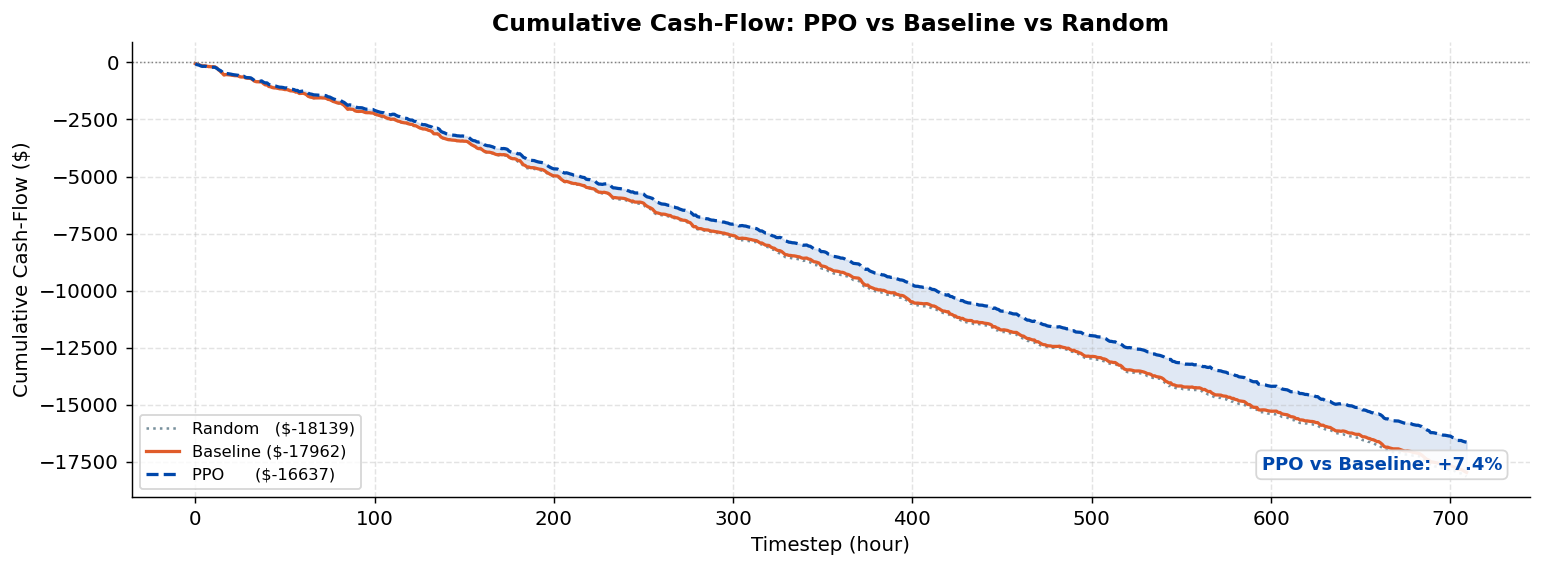

✅ G-1 saved


In [ ]:
# ── G-1  Cumulative cash-flow (3 controllers) ────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))
steps = np.arange(len(baseline_cumsum))
ax.plot(steps, random_cumsum,   color=C_RAND, lw=1.4, ls=":", label=f"Random   (${random_total:.0f})")
ax.plot(steps, baseline_cumsum, color=C_BASE, lw=1.8,         label=f"Baseline (${baseline_total:.0f})")
ax.plot(steps, ppo_cumsum,      color=C_PPO,  lw=1.8, ls="--",label=f"PPO      (${ppo_total:.0f})")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.fill_between(steps, baseline_cumsum, ppo_cumsum,
                where=(ppo_cumsum > baseline_cumsum), alpha=0.12, color=C_PPO)
ax.fill_between(steps, baseline_cumsum, ppo_cumsum,
                where=(ppo_cumsum < baseline_cumsum), alpha=0.12, color=C_BASE)
ax.set_title("Cumulative Cash-Flow: PPO vs Baseline vs Random", fontsize=13, fontweight="bold")
ax.set_xlabel("Timestep (hour)"); ax.set_ylabel("Cumulative Cash-Flow ($)")
ax.legend(fontsize=9)
ax.annotate(f"PPO vs Baseline: {savings_pct:+.1f}%",
            xy=(0.98, 0.06), xycoords="axes fraction", ha="right", fontsize=10, fontweight="bold",
            color=C_PPO if savings_pct >= 0 else C_BASE,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))
fig.tight_layout(); fig.savefig("G1_financial_comparison.png", bbox_inches="tight")
plt.show(); print("✅ G-1 saved")


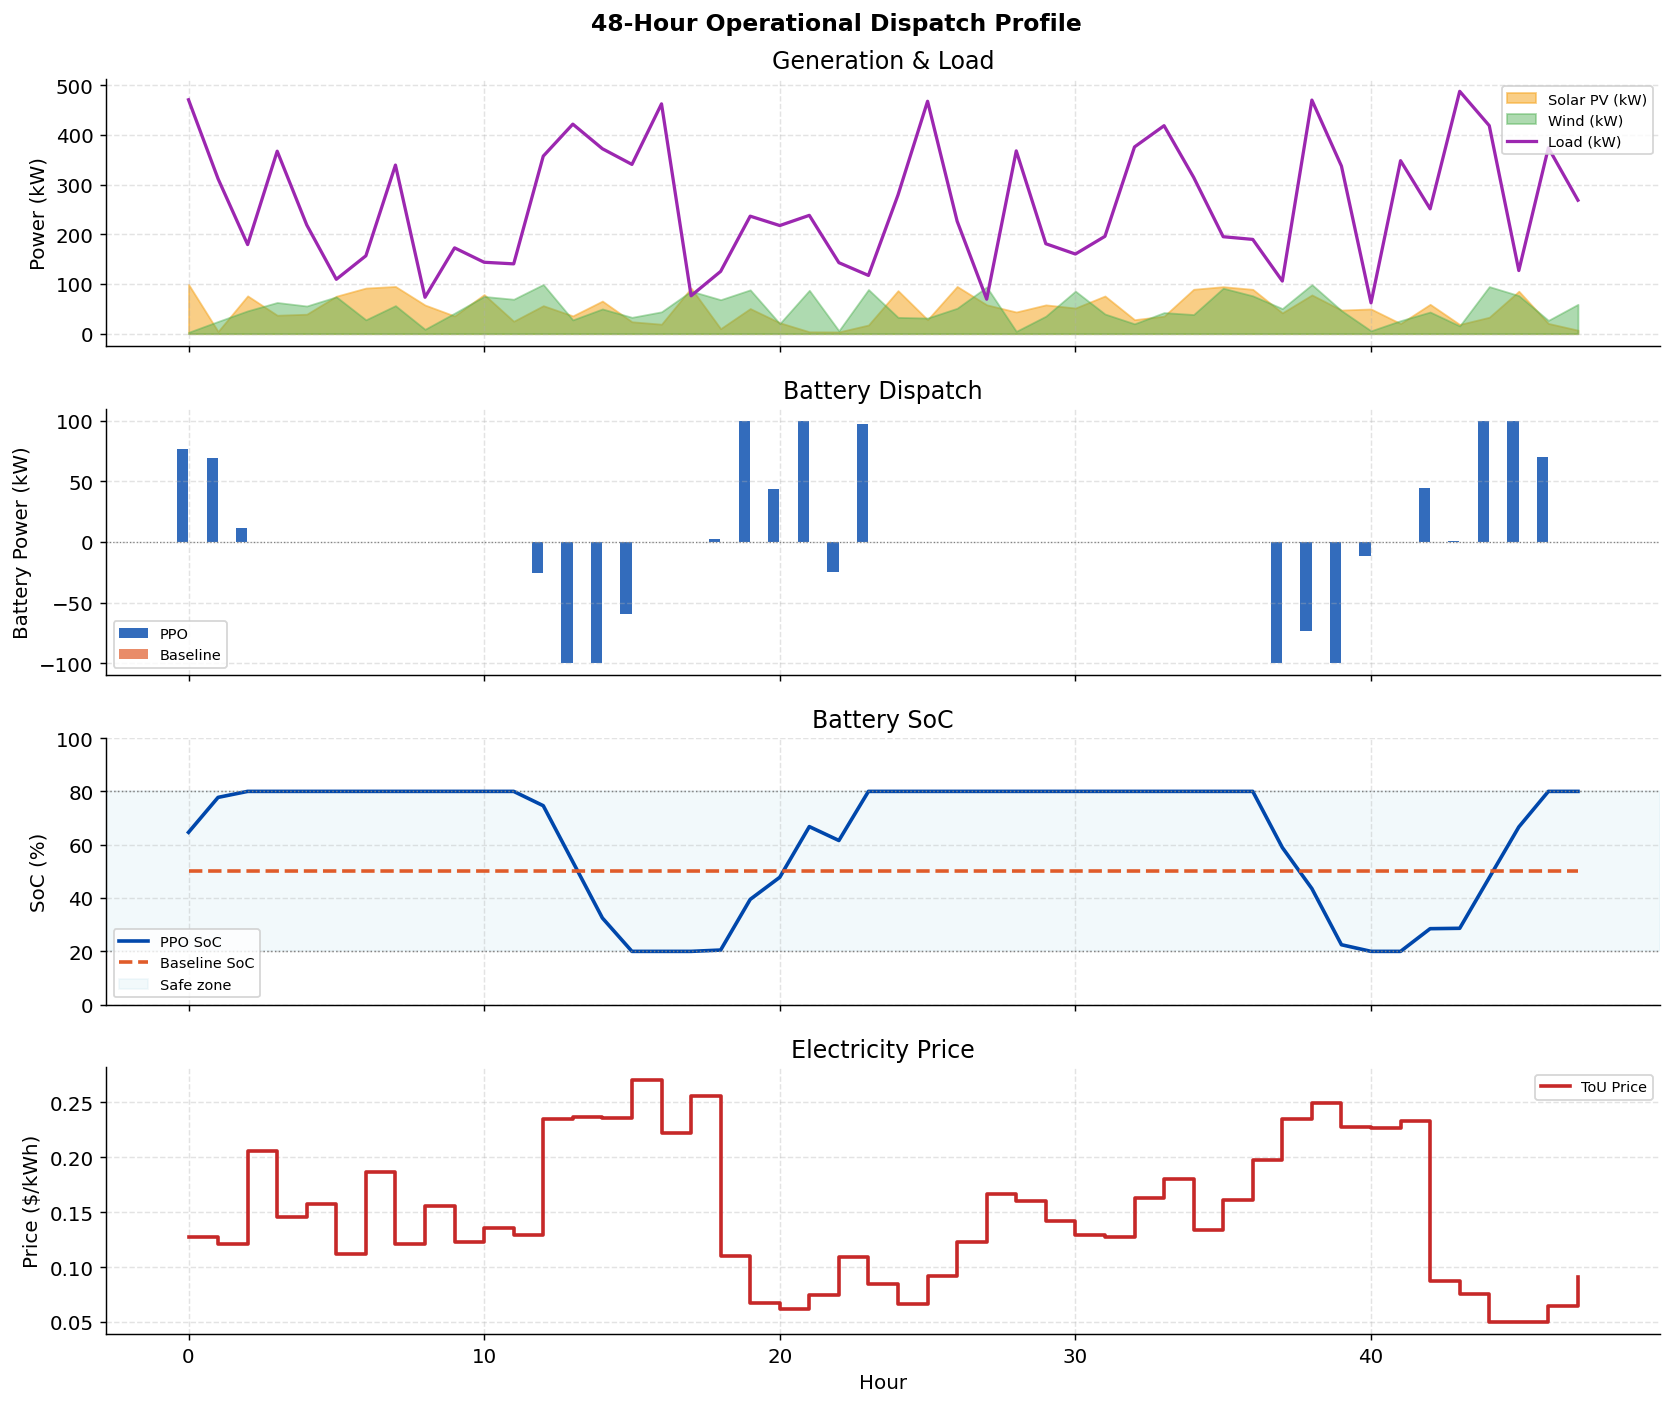

✅ G-2 saved


In [ ]:
# ── G-2  48-hour dispatch profile ────────────────────────────
WINDOW = 48; idx = slice(0, WINDOW)
ts   = df_test.iloc[idx].reset_index(drop=True)
x    = np.arange(WINDOW)

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
fig.suptitle("48-Hour Operational Dispatch Profile", fontsize=13, fontweight="bold")

axes[0].fill_between(x, ts["solar_pv_output"],  alpha=0.55, color=C_SOLAR, label="Solar PV (kW)")
axes[0].fill_between(x, ts["wind_power_output"], alpha=0.45, color=C_WIND,  label="Wind (kW)")
axes[0].plot(x, ts["grid_load_demand"], color=C_LOAD, lw=1.8, label="Load (kW)")
axes[0].set_ylabel("Power (kW)"); axes[0].set_title("Generation & Load"); axes[0].legend(fontsize=8)

axes[1].bar(x - 0.2, ppo_res["bat_hist"][idx],      width=0.38, color=C_PPO,  alpha=0.8, label="PPO")
axes[1].bar(x + 0.2, baseline_res["bat_hist"][idx],  width=0.38, color=C_BASE, alpha=0.7, label="Baseline")
axes[1].axhline(0, color="gray", lw=0.7, ls=":")
axes[1].set_ylabel("Battery Power (kW)"); axes[1].set_title("Battery Dispatch"); axes[1].legend(fontsize=8)

axes[2].plot(x, np.array(ppo_res["soc_hist"][idx])      * 100, color=C_PPO,  lw=2, label="PPO SoC")
axes[2].plot(x, np.array(baseline_res["soc_hist"][idx]) * 100, color=C_BASE, lw=2, ls="--", label="Baseline SoC")
axes[2].axhspan(20, 80, color="lightblue", alpha=0.15, label="Safe zone")
axes[2].axhline(20, color="gray", lw=0.8, ls=":"); axes[2].axhline(80, color="gray", lw=0.8, ls=":")
axes[2].set_ylim(0, 100); axes[2].set_ylabel("SoC (%)"); axes[2].set_title("Battery SoC"); axes[2].legend(fontsize=8)

axes[3].step(x, ts["price_actual"].values, color=C_PRICE, lw=2, where="post", label="ToU Price")
axes[3].set_ylabel("Price ($/kWh)"); axes[3].set_xlabel("Hour"); axes[3].set_title("Electricity Price"); axes[3].legend(fontsize=8)

fig.tight_layout(); fig.savefig("G2_dispatch_profile.png", bbox_inches="tight")
plt.show(); print("✅ G-2 saved")


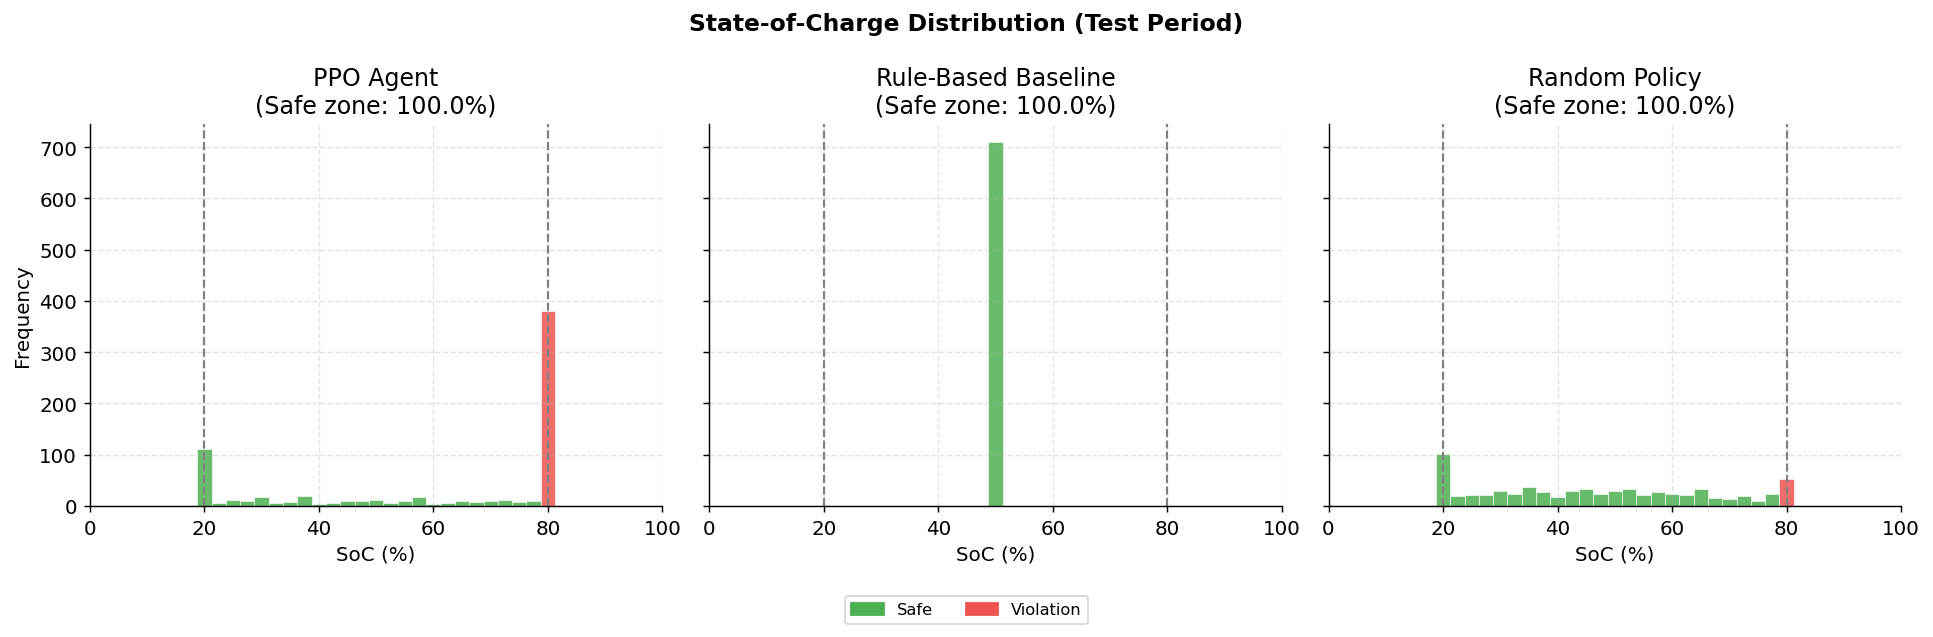

✅ G-3 saved


In [ ]:
# ── G-3  SoC distribution (3 panels) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle("State-of-Charge Distribution (Test Period)", fontsize=13, fontweight="bold")

for ax, data, label, iz in zip(
    axes,
    [soc_ppo_pct, soc_base_pct, soc_rand_pct],
    ["PPO Agent", "Rule-Based Baseline", "Random Policy"],
    [in_zone_ppo, in_zone_base, in_zone_rand],
):
    bins = np.linspace(0, 100, 41)
    counts, edges = np.histogram(data, bins=bins)
    colors = ["#4CAF50" if (edges[i] >= 20 and edges[i+1] <= 80) else "#EF5350"
              for i in range(len(counts))]
    ax.bar(edges[:-1], counts, width=np.diff(edges), color=colors, alpha=0.85, edgecolor="white", lw=0.4)
    ax.axvline(20, color="gray", lw=1.2, ls="--"); ax.axvline(80, color="gray", lw=1.2, ls="--")
    ax.set_title(f"{label}\n(Safe zone: {iz:.1f}%)"); ax.set_xlabel("SoC (%)"); ax.set_xlim(0, 100)

axes[0].set_ylabel("Frequency")
fig.legend(handles=[mpatches.Patch(color="#4CAF50", label="Safe"), mpatches.Patch(color="#EF5350", label="Violation")],
           loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig("G3_soc_distribution.png", bbox_inches="tight")
plt.show(); print("✅ G-3 saved")


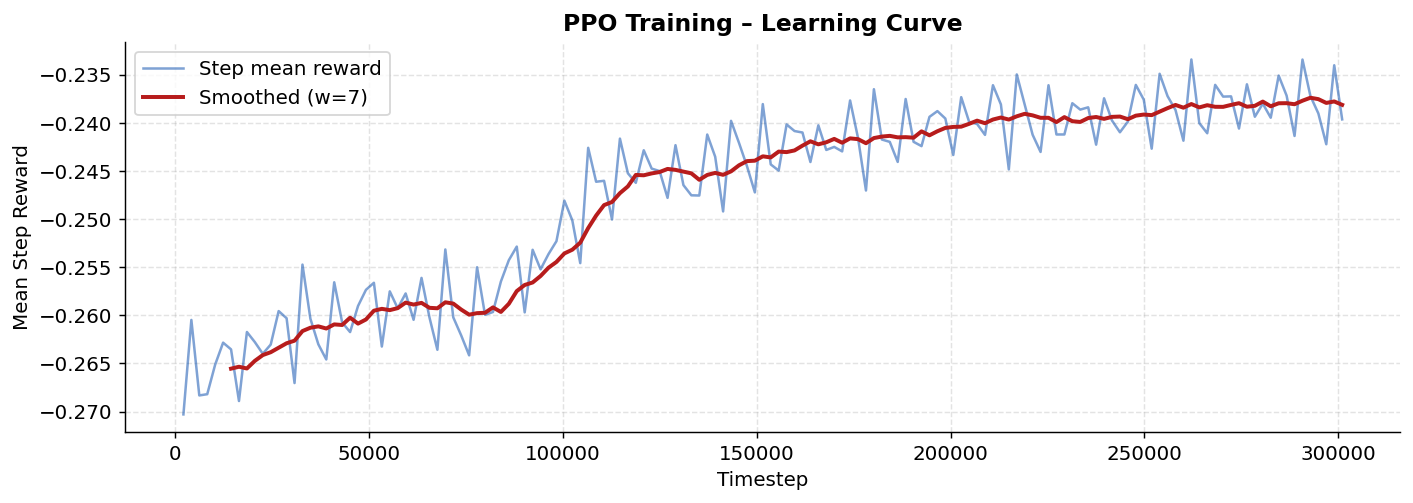

✅ G-4 saved


In [ ]:
# ── G-4  Learning curve ───────────────────────────────────────
if reward_cb.reward_log:
    ts_log, rew_log = zip(*reward_cb.reward_log)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(ts_log, rew_log, color=C_PPO, lw=1.4, alpha=0.5, label="Step mean reward")
    w  = max(1, len(rew_log) // 20)
    sm = np.convolve(rew_log, np.ones(w) / w, mode="valid")
    ax.plot(ts_log[w-1:], sm, color="#B71C1C", lw=2.2, label=f"Smoothed (w={w})")
    ax.set_title("PPO Training – Learning Curve", fontsize=13, fontweight="bold")
    ax.set_xlabel("Timestep"); ax.set_ylabel("Mean Step Reward"); ax.legend()
    fig.tight_layout(); fig.savefig("G4_learning_curve.png", bbox_inches="tight")
    plt.show(); print("✅ G-4 saved")


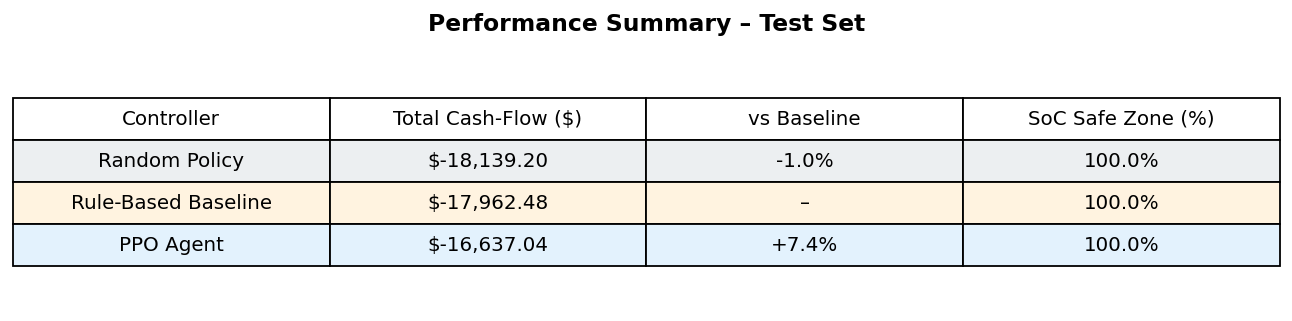

✅ G-5 saved

✅  Block G complete – all plots generated.


In [ ]:
# ── G-5  Summary table ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")
rows = [
    ["Random Policy",      f"${random_total:,.2f}",   f"{(random_total-baseline_total)/abs(baseline_total)*100:+.1f}%",  f"{in_zone_rand:.1f}%"],
    ["Rule-Based Baseline",f"${baseline_total:,.2f}",  "–",                                                               f"{in_zone_base:.1f}%"],
    ["PPO Agent",          f"${ppo_total:,.2f}",       f"{savings_pct:+.1f}%",                                            f"{in_zone_ppo:.1f}%"],
]
tbl = ax.table(
    cellText=rows,
    colLabels=["Controller", "Total Cash-Flow ($)", "vs Baseline", "SoC Safe Zone (%)"],
    cellColours=[["#ECEFF1"]*4, ["#FFF3E0"]*4, ["#E3F2FD"]*4],
    loc="center", cellLoc="center",
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.0)
ax.set_title("Performance Summary – Test Set", fontsize=13, fontweight="bold", pad=14)
fig.tight_layout(); fig.savefig("G5_summary_table.png", bbox_inches="tight")
plt.show(); print("✅ G-5 saved")

print("\n✅  Block G complete – all plots generated.")


## 🏁 Final Results

In [ ]:
print("\n" + "="*60)
print("  🏁  FINAL RESULTS")
print("="*60)
print(f"  Random    cash-flow : ${random_total:>10.2f}")
print(f"  Baseline  cash-flow : ${baseline_total:>10.2f}")
print(f"  PPO Agent cash-flow : ${ppo_total:>10.2f}")
if savings_pct >= 0:
    print(f"  ✅ PPO improved over baseline by {savings_pct:.2f}%")
else:
    print(f"  ⚠️  PPO underperformed baseline by {abs(savings_pct):.2f}%")
    print("     → Try more timesteps or adjust reward weights.")
print(f"  SoC safe zone → PPO: {in_zone_ppo:.1f}% | Baseline: {in_zone_base:.1f}% | Random: {in_zone_rand:.1f}%")
print("="*60)



  🏁  FINAL RESULTS
  Random    cash-flow : $ -18139.20
  Baseline  cash-flow : $ -17962.48
  PPO Agent cash-flow : $ -16637.04
  ✅ PPO improved over baseline by 7.38%
  SoC safe zone → PPO: 100.0% | Baseline: 100.0% | Random: 100.0%
